CCA(Complete Case Analysis): discard obsv with any missing value

Assumptions:
- Data missing completely at random (MCAR)
- Generally <5% data missing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [3]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [4]:
df.shape

(19158, 13)

In [5]:
cols=[col for col in df.columns if df[col].isnull().mean()<0.05 and df[col].isnull().mean()>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [6]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
11938,0.698,no_enrollment,High School,4.0,45.0
16323,0.624,no_enrollment,Graduate,5.0,160.0
11301,0.920,Full time course,Graduate,6.0,117.0
6400,0.624,NaN,Graduate,7.0,65.0
7093,0.689,no_enrollment,Graduate,9.0,56.0


In [7]:
#checking size of dataset if rows are dropped
len(df[cols].dropna())/len(df)

0.8968577095730244

In [8]:
new_df=df[cols].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

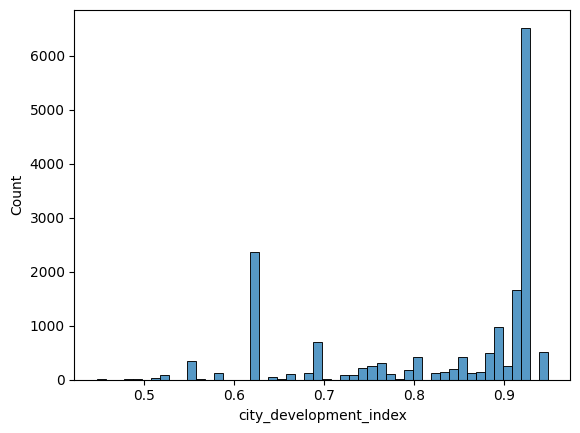

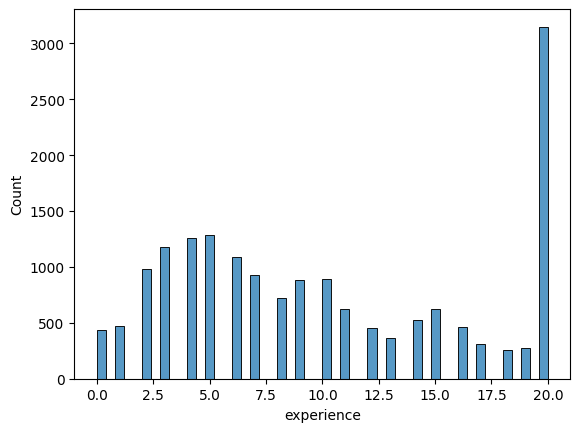

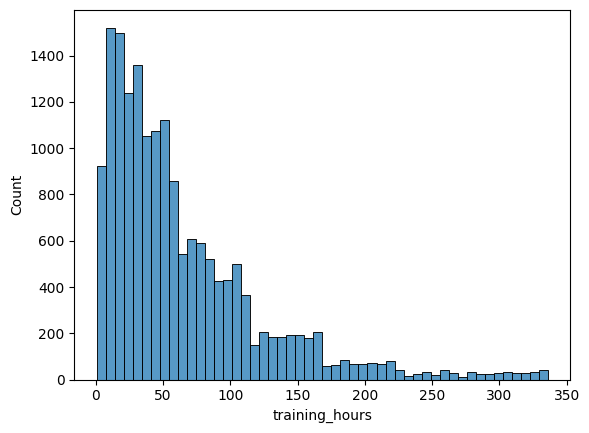

In [9]:
import seaborn as sns
for col in new_df.select_dtypes(include='number'):
    sns.histplot(new_df[col],bins=50)
    plt.show()

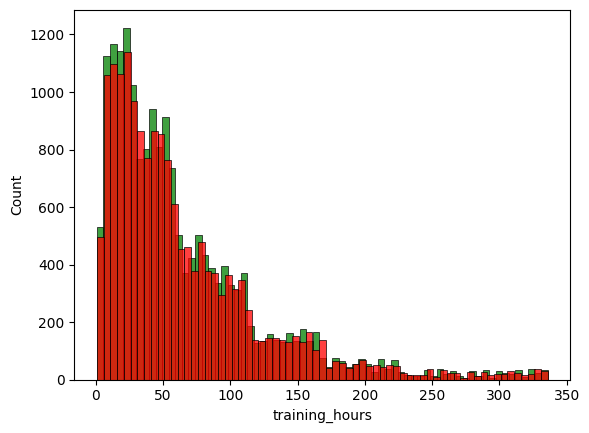

In [10]:
sns.histplot(df['training_hours'],color='green')
sns.histplot(new_df['training_hours'],color='red')
plt.show()

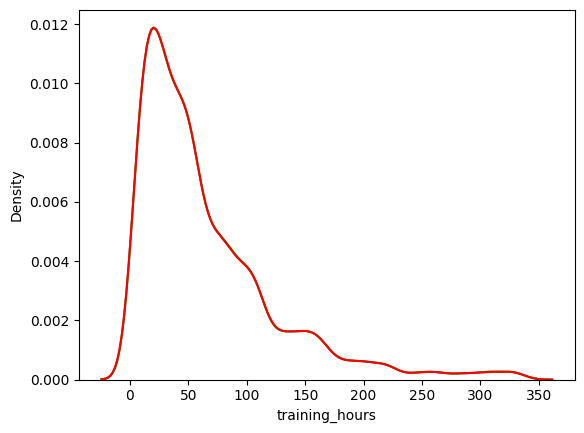

In [11]:
sns.kdeplot(df['training_hours'],color='green')
sns.kdeplot(new_df['training_hours'],color='red')
plt.show()

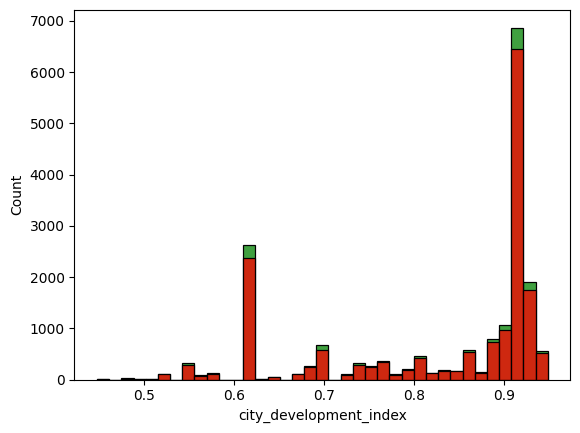

In [12]:
sns.histplot(df['city_development_index'],color='green')
sns.histplot(new_df['city_development_index'],color='red')
plt.show()

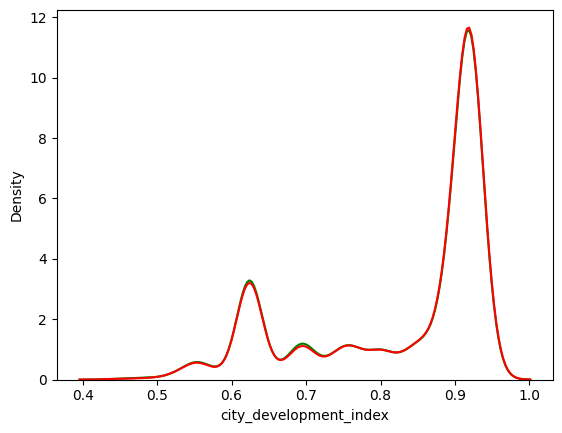

In [13]:
sns.kdeplot(df['city_development_index'],color='green')
sns.kdeplot(new_df['city_development_index'],color='red')
plt.show()

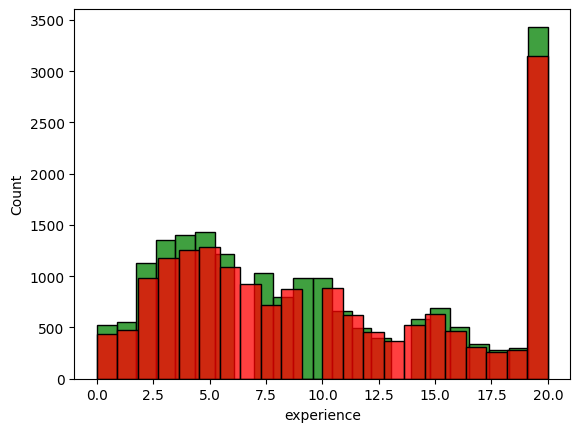

In [14]:
sns.histplot(df['experience'],color='green')
sns.histplot(new_df['experience'],color='red')
plt.show()

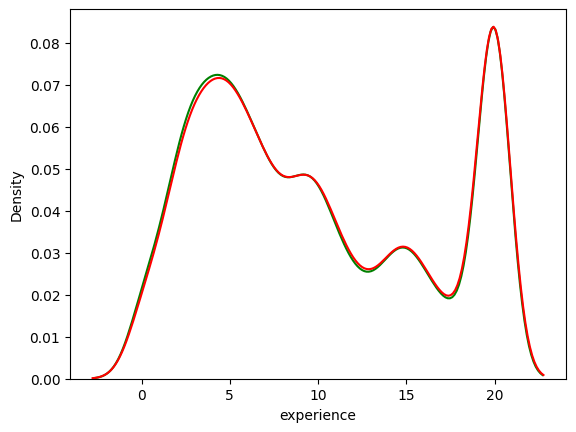

In [15]:
sns.kdeplot(df['experience'],color='green')
sns.kdeplot(new_df['experience'],color='red')
plt.show()

In [16]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
8850,0.827,no_enrollment,Graduate,20.0,139.0
8388,0.897,no_enrollment,High School,4.0,24.0
18548,0.926,no_enrollment,Graduate,13.0,77.0
13662,0.920,no_enrollment,Graduate,4.0,57.0
18747,0.794,Full time course,Graduate,1.0,78.0


In [17]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [18]:
temp=pd.concat([
    df['enrolled_university'].value_counts()/len(df),
    new_df['enrolled_university'].value_counts()/len(df)
], axis=1)

temp.columns=['original','cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469
